# Análise de Dados com Python [T1]
## Mini-Projeto Avaliativo - Módulo 1 - Semana 07
### Rodrigo Vieira

## Obejtivo
#### realizar uma Análise Exploratória da base Varejo seguindo etapas claras, documentadas e reproduzíveis.

In [1]:
# Imports das Bibliotecas Necessárias

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import kagglehub
import shutil
from pathlib import Path

In [2]:
# Download e carga da base

# Define o caminho da pasta de dados
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)

# Baixa o dataset do Kaggle
path = kagglehub.dataset_download('namespaiva/base-varejo')

# Procura pelo arquivo CSV dentro da pasta baixada
# Prioriza 'Varejo.csv' se existir, caso contrário pega o primeiro CSV encontrado
path_obj = Path(path)
csv_files = list(path_obj.rglob('*.csv'))

if not csv_files:
    raise FileNotFoundError('Nenhum arquivo CSV encontrado no dataset.')

# Seleciona o arquivo alvo
target_file = next((f for f in csv_files if f.name == 'Varejo.csv'), csv_files[0])

# Define o caminho final e copia o arquivo
final_path = data_dir / 'Varejo.csv'
shutil.copy2(target_file, final_path)

# Carrega os dados em um DataFrame
df = pd.read_csv(final_path, sep=';', encoding='utf-8')

# Exibe as primeiras linhas
df.head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


In [3]:
# Drop de colunas não nomeadas 'Unnamed' (verificando o dataset no kaggle, essas colunas não existem)
# Em uma checagem prévia essas colunas aparecem com todos os registros ausentes.
df = df.loc[:, ~df.columns.str.startswith('Unnamed:')]

### Problema 1
O arquivo baixado carrega um Dataset com 4 colunas inexistentes. 

Após verificar que todas as linhas dessas colunas representam valores ausentes, eu decidi eliminar essas colunas

In [4]:
# Verifica a estrutura básica do df.
df.shape

(830000, 10)

In [5]:
# exibe os tipo de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   DATA       830000 non-null  str  
 1   CO_ID      830000 non-null  int64
 2   CL_ID      830000 non-null  int64
 3   CL_GENERO  830000 non-null  str  
 4   CL_EC      830000 non-null  int64
 5   CL_FHL     830000 non-null  int64
 6   CL_SEG     830000 non-null  str  
 7   PR_ID      830000 non-null  int64
 8   PR_CAT     830000 non-null  str  
 9   PR_NOME    830000 non-null  str  
dtypes: int64(5), str(5)
memory usage: 63.3 MB


In [6]:
# Contagem de valores ausentes
# Aparentemente não há valores ausentes
df.isna().sum().sort_values(ascending=False)

DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

In [7]:
# Verificando valores únicos na coluna PR_CAT
# O valor '#N/D' chama a atenção. Será um valor ausente??
df['PR_CAT'].value_counts()

PR_CAT
ALIMENTOS     434767
HIGIENE       155574
LIMPEZA       145754
BEBIDAS        43299
PET            32399
ACESSORIOS     14557
#N/D            3650
Name: count, dtype: int64

In [8]:
# Verificando valores únicos na coluna PR_NOME
# O valor '#N/D' chama a atenção. Será um valor ausente??
# É a mesma quantidade de linhas da coluna PR_CAT (3650)
df['PR_NOME'].value_counts()

PR_NOME
PRESUNTO COZIDO          14381
SARDINHA                  7490
GEL                       7399
BANANA                    7385
DESENGORDURANTE           7378
                         ...  
#N/D                      3650
ABSORVENTE                3639
ALCOOL                    3611
ALIMENTO PARA PASSARO     3605
ALHO                      3574
Name: count, Length: 118, dtype: int64

In [9]:
# verificando as demais colunas onde os valores de PR_CAT e PR_NOME são iguais a '#N/D'
# O Valos '#N/D' possui um PR_ID único (107), o que indica que é um valor válido. 
df[df['PR_CAT'] == '#N/D'].head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
82,01/02/2019,1078,290,F,1,0,B,107,#N/D,#N/D
223,01/02/2019,1103,957,M,2,3,B,107,#N/D,#N/D
640,01/02/2019,1482,453,F,1,0,B,107,#N/D,#N/D
857,01/02/2019,1683,438,F,1,0,B,107,#N/D,#N/D
917,01/02/2019,1793,608,F,3,0,C,107,#N/D,#N/D


### Problema 2

Após analisar a base, o valor #N/D nas colunas PR_CAT e PR_NOME chamou atenção por aparecer 3.650 vezes nas duas colunas. Primeiro, considerei que pudesse ser um valor ausente, mas ao olhar melhor as outras informações dessas linhas, vi que ele está ligado a um PR_ID específico (107), o que indica que esse registro existe de fato na base. 

Mesmo assim, como esse grupo representa uma parte pequena dos dados e não contribui para a análise das categorias de produtos, optei por remover as linhas em que PR_CAT e PR_NOME são iguais a #N/D para deixar a análise mais limpa e objetiva.

In [10]:
# Aliminando linhas onde 'PR_CAT' e 'PR_NOME' = '#N/D'
df = df[~((df['PR_CAT'] == '#N/D') & (df['PR_NOME'] == '#N/D'))].copy()

In [11]:
# Nova verificação da estrutura básica do df.
print(df.shape)
df.info()

(826350, 10)
<class 'pandas.DataFrame'>
Index: 826350 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   DATA       826350 non-null  str  
 1   CO_ID      826350 non-null  int64
 2   CL_ID      826350 non-null  int64
 3   CL_GENERO  826350 non-null  str  
 4   CL_EC      826350 non-null  int64
 5   CL_FHL     826350 non-null  int64
 6   CL_SEG     826350 non-null  str  
 7   PR_ID      826350 non-null  int64
 8   PR_CAT     826350 non-null  str  
 9   PR_NOME    826350 non-null  str  
dtypes: int64(5), str(5)
memory usage: 69.4 MB


In [12]:
# Nova contagem de valores ausentes
# Verificar se não criamos valores ausntes inadivertidamente
df.isna().sum().sort_values(ascending=False)

DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

In [13]:
# Exibe as primeiras linhas
df.head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


### Ajustando os Tipos de Dados

Na própria página do Kaggle, no arquivo 'Projeto III - Anlise Exploratria de Dados Utilizando o Python ou RStudio.pdf', encontrei essa descrição que condiz com um dicionário de dados para o Dataset Varejo.

- DATA: Data da compra;
- CO_ID: Identificação do número de compra (número da nota fiscal);
- CL_ID: Identificação do cliente (número do cliente);
- CL_GENERO: Sexo biológico informado pelo cliente; 
- CL_EC: Estado civil do cliente:
    - 1: Casado ou união estával;
    - 2: Divorciado;
    - 3: Separado;
    - 4: Solteiro;
    - 5: Viúvo.
- CL_FHL: Número de filhos do cliente;
- CL_SEG: Segmentação econômica do cliente (classe A, B ou C);
- PR_ID: Código do produto (SKU) adquirido;
- PR_CAT: Categoria do produto adquirido;
- PR_NOME: Nome do produto adquirido.

Vou ajustar os tipos de dados a partir desse dicionário.

In [14]:
# Ajustando os tipos de dados conforme o dicionário encontrado.

# Ajuste da coluna de data
df['DATA'] = pd.to_datetime(df['DATA'])

# Conversão de IDs para string
for col in ['CO_ID', 'CL_ID', 'PR_ID']:
    df[col] = df[col].astype('string')

# Mapeamento e conversão de estado civil
mapa_ec = {1: 'Casado/União estável', 2: 'Divorciado', 3: 'Separado', 4: 'Solteiro', 5: 'Viúvo'}
df['CL_EC'] = df['CL_EC'].map(mapa_ec).astype('category')

# Otimização de número de filhos
df['CL_FHL'] = pd.to_numeric(df['CL_FHL'], downcast='integer')

# Conversão de colunas categóricas de texto
cat_cols = ['CL_GENERO', 'CL_SEG', 'PR_CAT', 'PR_NOME']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().astype('category')

In [15]:
# Nova verificação sobre valores ausentes
df.isna().sum().sort_values(ascending=False)

DATA         482566
CO_ID             0
CL_ID             0
CL_GENERO         0
CL_EC             0
CL_FHL            0
CL_SEG            0
PR_ID             0
PR_CAT            0
PR_NOME           0
dtype: int64

In [16]:
# Exibição dos resultados
print(df.shape)
df.info()

(826350, 10)
<class 'pandas.DataFrame'>
Index: 826350 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       343784 non-null  datetime64[us]
 1   CO_ID      826350 non-null  string        
 2   CL_ID      826350 non-null  string        
 3   CL_GENERO  826350 non-null  category      
 4   CL_EC      826350 non-null  category      
 5   CL_FHL     826350 non-null  int8          
 6   CL_SEG     826350 non-null  category      
 7   PR_ID      826350 non-null  string        
 8   PR_CAT     826350 non-null  category      
 9   PR_NOME    826350 non-null  category      
dtypes: category(5), datetime64[us](1), int8(1), string(3)
memory usage: 36.3 MB


In [17]:
# Exibe as primeiras linhas pós ajustes
df.head()

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-01-02,1000,534,M,Solteiro,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-01-02,1000,534,M,Solteiro,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-01-02,1000,534,M,Solteiro,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-01-02,1000,534,M,Solteiro,1,C,4,ALIMENTOS,ABACAXI
4,2019-01-02,1000,534,M,Solteiro,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


count    826350.000000
mean          1.146420
std           1.416888
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000
Name: CL_FHL, dtype: float64


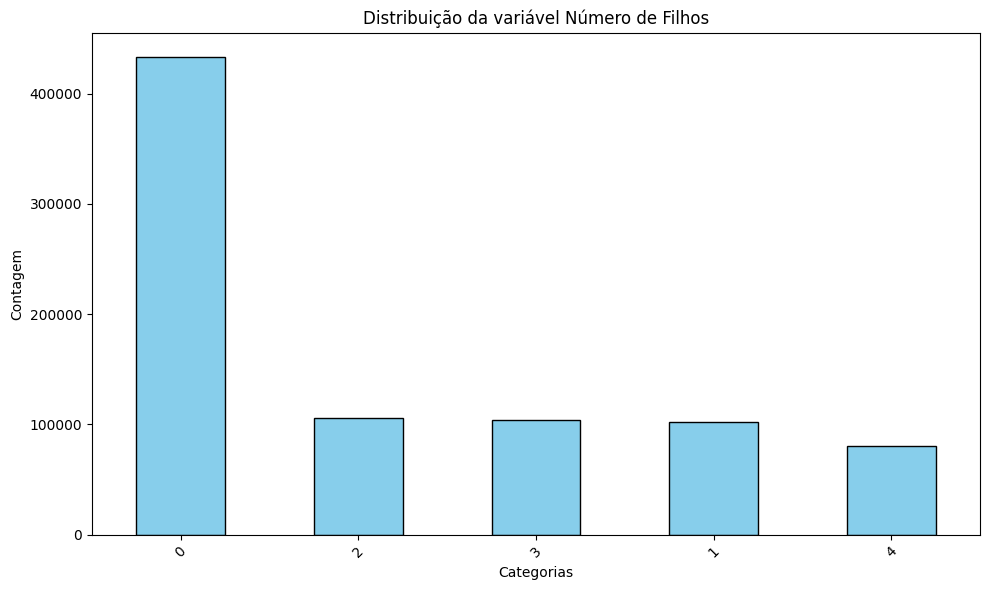

In [48]:
# Exibe o resumo estatístico da coluna
print(df['CL_FHL'].describe())

# Conta as ocorrências de cada categoria
contagem = df['CL_FHL'].value_counts()

# Cria o gráfico de barras
plt.figure(figsize=(10, 6))
contagem.plot(kind='bar', color='skyblue', edgecolor='black')

# Adiciona títulos e rótulos
plt.title('Distribuição da variável Número de Filhos')
plt.ylabel('Contagem')
plt.xlabel('Categorias')

# Ajusta a rotação dos rótulos e o layout
plt.xticks(rotation=45)
plt.tight_layout()

# Exibe o gráfico
plt.show()

### Observações:
O número de filhos apresenta forte concentração em valores baixos, com mediana igual a 0, média de 1,15 e desvio padrão de 1,42, indicando que a maior parte dos indivíduos não possui filhos ou tem poucos filhos, com valores variando de 0 a 4.

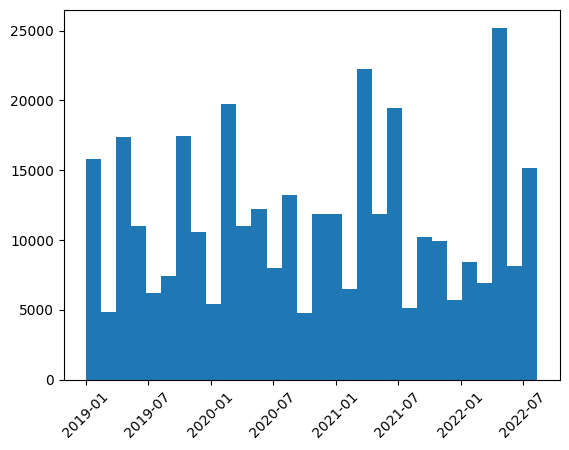

In [54]:
# Visualizar a distribuição dos dados pela coluna DATA
plt.hist(pd.to_datetime(df['DATA']), bins=30); plt.xticks(rotation=45)
plt.show()

### Observações
As vendas apresentaram oscilação ao longo do tempo, com alternância entre períodos de queda e crescimento, culminando em um pico expressivo no final da série.

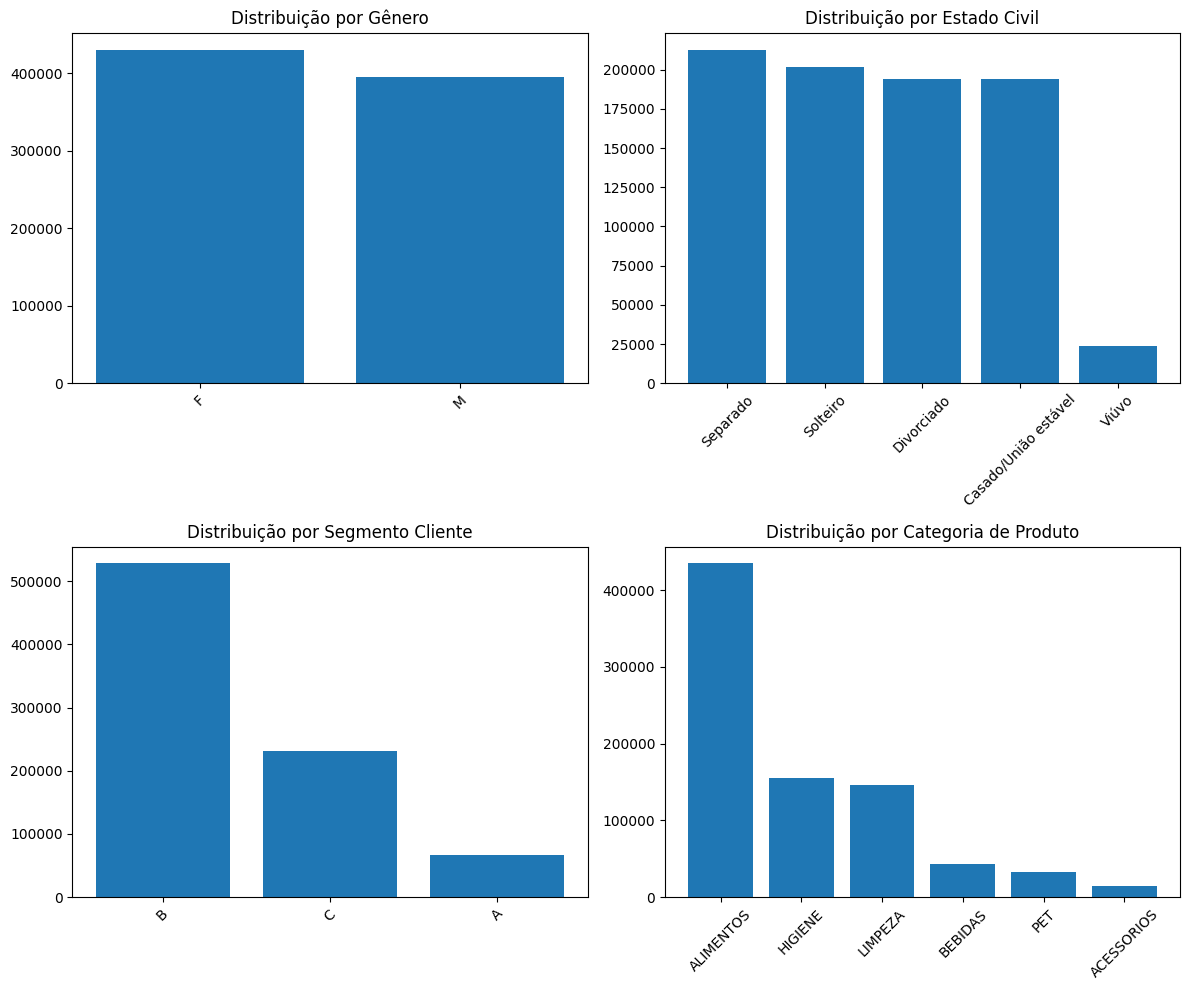

In [51]:
# Visualizar os dados pelas colunas categóricas
colunas = ['CL_GENERO', 'CL_EC', 'CL_SEG', 'PR_CAT']
titulos = {
    'CL_GENERO': 'Gênero',
    'CL_EC': 'Estado Civil',
    'CL_SEG': 'Segmento Cliente',
    'PR_CAT': 'Categoria de Produto'
}

# Cria a figura com grade 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Itera sobre as colunas e plota os gráficos
for i, col in enumerate(colunas):
    if col in df.columns:
        counts = df[col].value_counts()
        axes[i].bar(counts.index.astype(str), counts.values)
        axes[i].set_title(f'Distribuição por {titulos[col]}')
        axes[i].tick_params(axis='x', rotation=45)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()

### Observações

A distribuição por Gênero não é totalmente igual, mas também não é muito desequilibrada. A principal mensagem do gráfico é: há uma leve predominância do gênero feminino.

A variável estado civil apresenta uma distribuição concentrada em quatro categorias principais com frequências semelhantes, com destaque para “Separado” como grupo mais numeroso, enquanto “Viúvo” aparece como uma categoria claramente minoritária, indicando uma forte assimetria apenas nesse último grupo.

A variável Segmento de Clientes apresenta uma distribuição fortemente concentrada no segmento B, que reúne a maior parte dos registros, enquanto o segmento C ocupa uma posição intermediária e o segmento A tem participação bem menor, indicando uma base de clientes bastante desigual entre os segmentos.

A variável Categoria de Produto apresenta uma distribuição fortemente concentrada em ALIMENTOS, que se destaca de forma muito expressiva em relação às demais categorias; HIGIENE e LIMPEZA formam um bloco intermediário com participação semelhante, enquanto BEBIDAS, PET e ACESSÓRIOS têm peso reduzido, indicando uma composição bastante desigual entre os grupos.

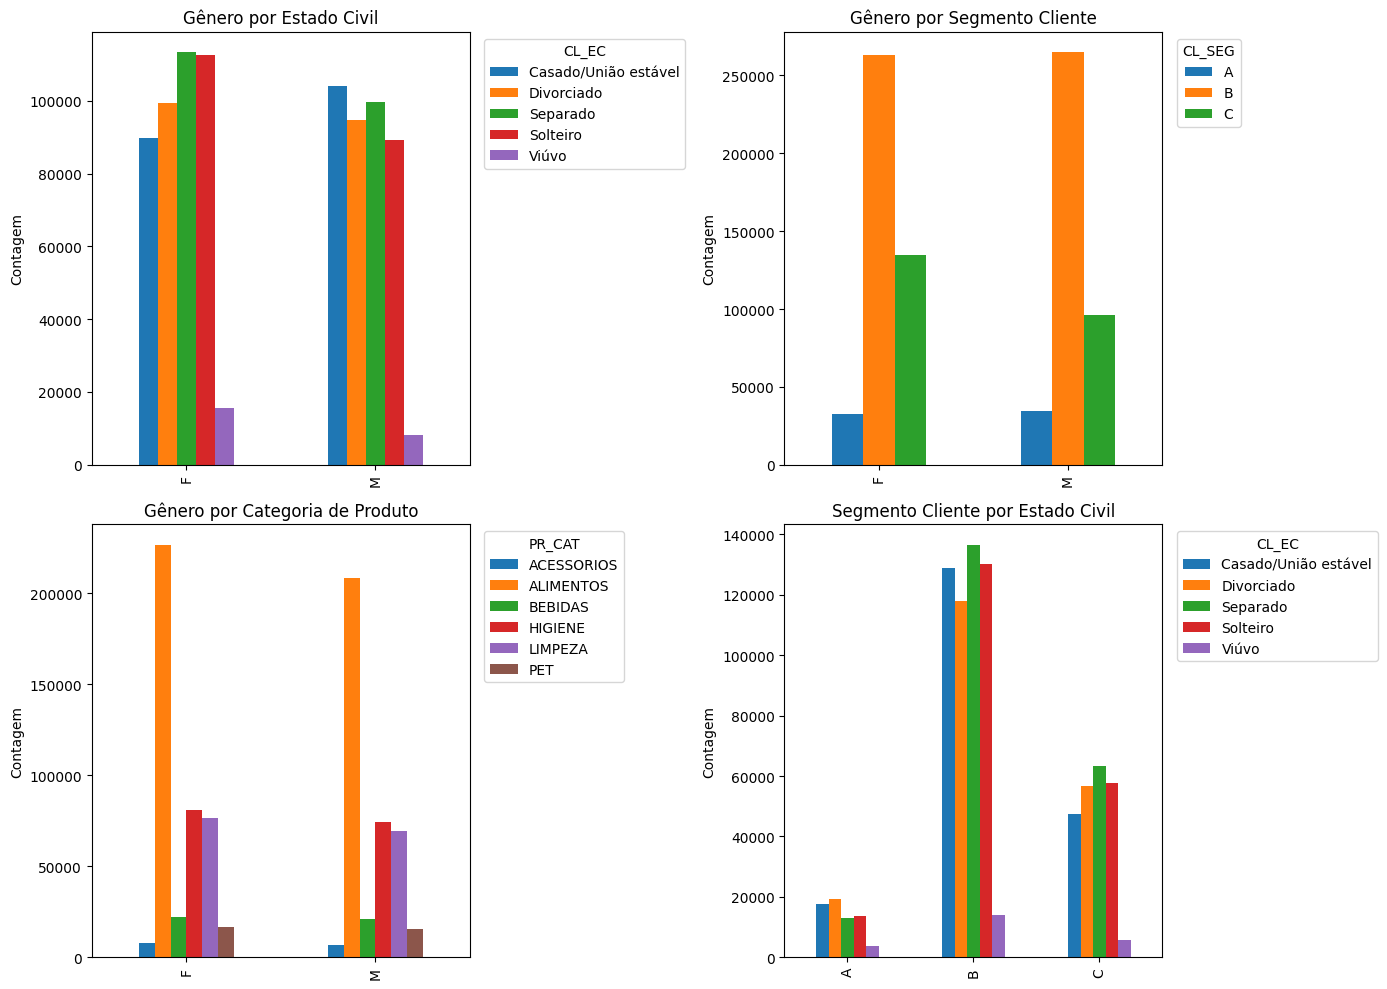

In [60]:
# Definindo os pares de colunas e os títulos correspondentes
pairs = [('CL_GENERO', 'CL_EC'), ('CL_GENERO', 'CL_SEG'), ('CL_GENERO', 'PR_CAT'), ('CL_SEG', 'CL_EC')]
titles = ['Gênero por Estado Civil', 'Gênero por Segmento Cliente', 'Gênero por Categoria de Produto', 'Segmento Cliente por Estado Civil']

# Criando a figura com subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Loop para gerar os gráficos
for i, (col1, col2) in enumerate(pairs):
    # Criando tabela cruzada e plotando barras
    ct = pd.crosstab(df[col1], df[col2])
    ct.plot(kind='bar', ax=axes[i])
    
    # Aplicando título e rótulos
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Contagem')
    axes[i].set_xlabel('')
    
    # Ajustando legenda
    axes[i].legend(title=col2, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Observações

**Gênero por Estado Civil**

O agrupamento Gênero por Estado Civil mostra um padrão bastante semelhante entre os dois gêneros, com maior concentração nas categorias Separado, Solteiro, Divorciado e Casado/União estável, enquanto Viúvo permanece visualmente como a menor faixa em ambos os grupos. As barras associadas ao gênero F tendem a aparecer ligeiramente mais altas do que as do gênero M, o que sugere que a base feminina é maior, mas sem alterar o desenho geral da distribuição entre os estados civis.

**Gênero por Segmento Cliente**

No agrupamento Gênero por Segmento Cliente, o segmento B aparece como o mais representativo para ambos os gêneros, seguido pelo segmento C, enquanto o segmento A tem participação bem menor. O comportamento visual é consistente entre F e M, indicando que a concentração no segmento B é uma característica estrutural da base e não algo específico de apenas um gênero, embora o gênero feminino apresente volume um pouco superior no total.

**Gênero por Categoria de Produto**

O gráfico Gênero por Categoria de Produto evidencia que ALIMENTOS domina amplamente a distribuição para os dois gêneros, enquanto HIGIENE e LIMPEZA formam um bloco intermediário de relevância e BEBIDAS, PET e ACESSÓRIOS aparecem com menor peso. A hierarquia visual se mantém de forma muito parecida entre F e M, sugerindo um padrão de consumo semelhante por gênero, com leve predominância do público feminino em volume.

**Segmento Cliente por Estado Civil**

No agrupamento Segmento Cliente por Estado Civil, o segmento B tende a concentrar as maiores contagens dentro das principais categorias de estado civil, reforçando seu peso dominante na base de clientes. Já os segmentos A e C aparecem com volumes menores, e a categoria Viúvo continua sendo a menos expressiva no conjunto, o que indica que a diferença entre segmentos é mais marcante do que a variação entre estados civis nas categorias mais representativas.

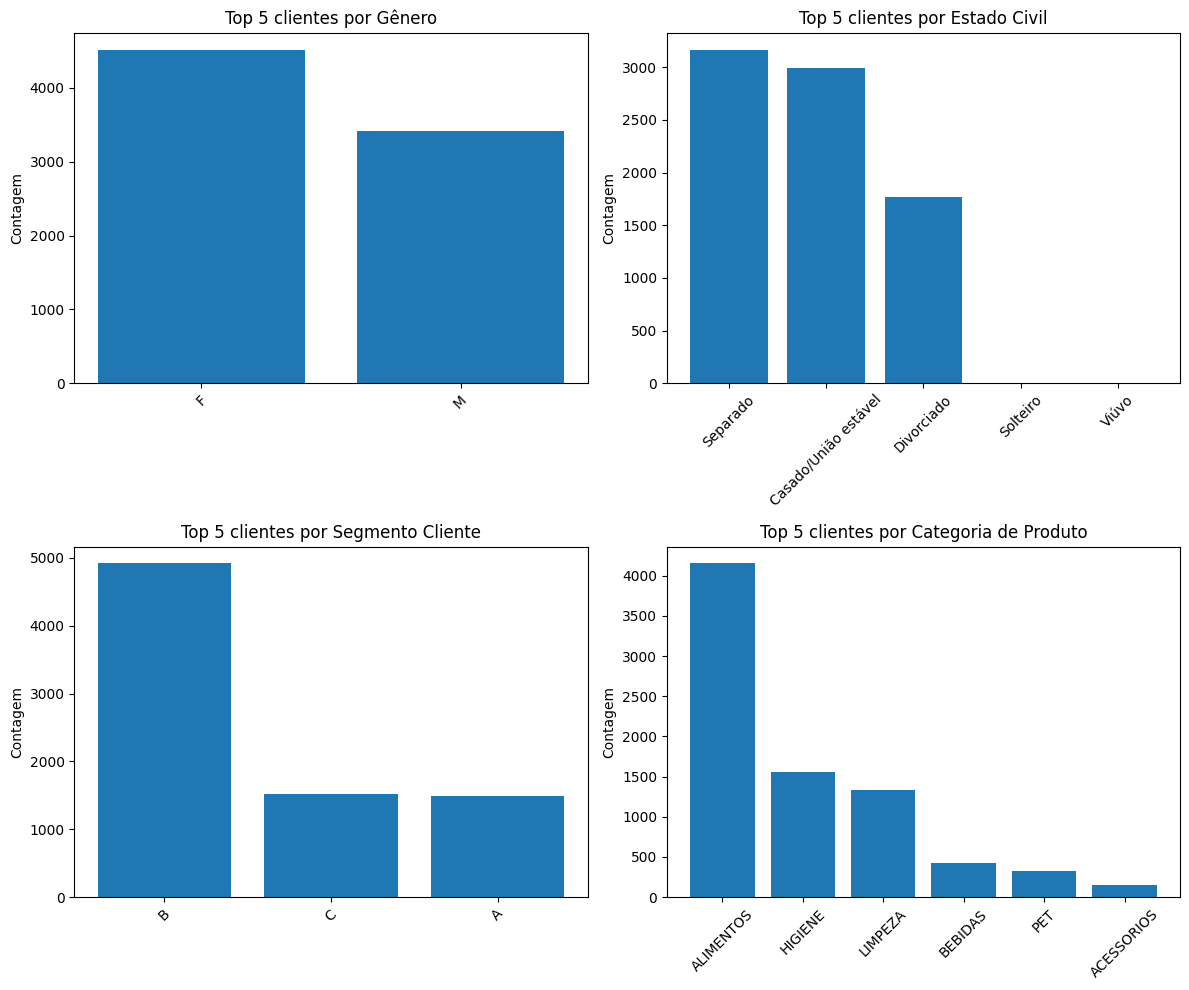

In [53]:
# Selecionar os 5 clientes com maior número de compras
top_5_ids = df['CL_ID'].value_counts().nlargest(5).index
df_top5 = df[df['CL_ID'].isin(top_5_ids)]

# Definir colunas e títulos correspondentes
colunas = ['CL_GENERO', 'CL_EC', 'CL_SEG', 'PR_CAT']
titulos = ['Top 5 clientes por Gênero', 'Top 5 clientes por Estado Civil', 'Top 5 clientes por Segmento Cliente', 'Top 5 clientes por Categoria de Produto']

# Criar grade 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plotar cada gráfico
for i, col in enumerate(colunas):
    contagem = df_top5[col].value_counts()
    axes[i].bar(contagem.index.astype(str), contagem.values)
    axes[i].set_title(titulos[i])
    axes[i].set_ylabel('Contagem')
    axes[i].tick_params(axis='x', rotation=45)

# Ajustar layout e exibir
plt.tight_layout()
plt.show()

### Observações

**Top 5 clientes por Gênero**

No agrupamento Top 5 clientes por Gênero, observa-se uma distribuição bastante próxima entre F e M, mas com leve predominância do gênero feminino. Isso sugere que, entre os Top 5 Clientes, há um equilíbrio relativo entre os gêneros, embora a participação feminina apareça um pouco mais forte no conjunto analisado.

**Top 5 clientes por Estado Civil**

No gráfico Top 5 clientes por Estado Civil, a categoria Separado aparece como a mais representativa, seguida por Casado/União estável e Divorciado, enquanto Solteiro e Viúvo têm presença muito reduzida. A leitura geral indica que, dentro do recorte dos Top 5 Clientes, há forte concentração em alguns estados civis específicos, com baixa dispersão nas categorias menos frequentes.

**Top 5 clientes por Segmento Cliente**

No agrupamento Top 5 clientes por Segmento Cliente, o segmento B domina de forma bastante clara, ficando muito acima dos segmentos C e A. O segmento C aparece em posição intermediária, enquanto o A tem participação bem menor, o que mostra que os Top 5 Clientes estão fortemente concentrados em um perfil de segmentação específico.

**Top 5 clientes por Categoria de Produto**

No gráfico Top 5 clientes por Categoria de Produto, a categoria ALIMENTOS se destaca amplamente como a mais representativa, seguida por HIGIENE e LIMPEZA, enquanto BEBIDAS, PET e ACESSORIOS aparecem com volumes menores. Isso indica que, entre os Top 5 Clientes, o consumo ou recorrência está muito concentrado em produtos de maior giro, especialmente na linha de alimentos.